In [4]:
import pandas as pd

df = pd.read_csv("../agent/dataset/data/travelsense_india_trips.csv")

print("=== UNIVARIATE ANALYSIS (One variable at a time) ===")
print("\n--- Summary Statistics for Numerical Data ---")
display(df[["distance_km", "travel_duration_hours", "trip_days", "total_cost_inr"]].describe().round(2))

print("\n--- Top 5 Most Visited States ---")
display(df["state"].value_counts().head(5))

print("\n\n=== BIVARIATE ANALYSIS (Two variables together) ===")
print("\n--- Correlation Matrix ---")
display(df[["distance_km", "travel_duration_hours", "trip_days", "total_cost_inr"]].corr().round(2))

=== UNIVARIATE ANALYSIS (One variable at a time) ===

--- Summary Statistics for Numerical Data ---


,distance_km,travel_duration_hours,trip_days,total_cost_inr
count,3000.00,3000.00,3000.00,3000.00
mean,1062.74,14.76,3.01,42478.00
std,512.80,10.38,1.29,31252.36
min,55.00,1.14,1.00,3306.00
25%,636.00,5.45,2.00,21269.00
50%,1030.50,12.36,3.00,33887.00
75%,1497.00,21.28,4.00,53878.25
max,2600.00,68.18,9.00,252896.00



--- Top 5 Most Visited States ---


state
Rajasthan      385
Karnataka      383
Kerala         305
Tamil Nadu     258
Uttarakhand    241
Name: count, dtype: int64



=== BIVARIATE ANALYSIS (Two variables together) ===

--- Correlation Matrix ---


,distance_km,travel_duration_hours,trip_days,total_cost_inr
distance_km,1.00,0.46,0.05,0.18
travel_duration_hours,0.46,1.00,0.03,-0.01
trip_days,0.05,0.03,1.00,0.40
total_cost_inr,0.18,-0.01,0.40,1.00


/var/folders/wq/npg502_x0w5cvxh39p1jy3n40000gn/T/ipykernel_56833/2095825634.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="trip_days", y="total_cost_inr", data=df, palette="viridis", ax=axes[1])


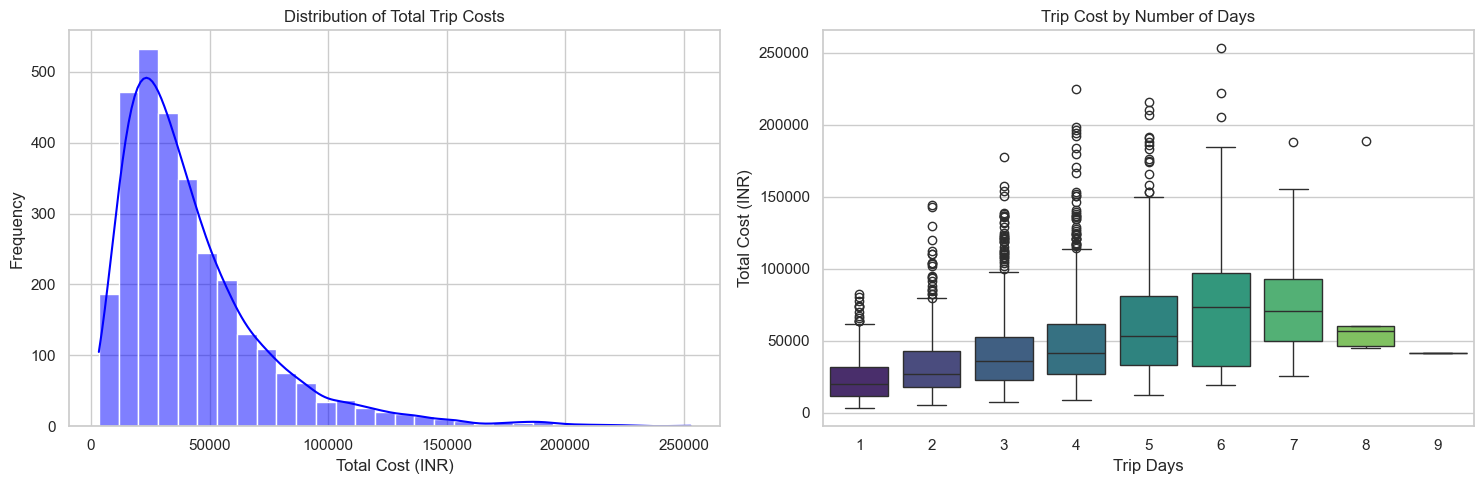

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df["total_cost_inr"], bins=30, kde=True, color="blue", ax=axes[0])
axes[0].set_title("Distribution of Total Trip Costs")
axes[0].set_xlabel("Total Cost (INR)")
axes[0].set_ylabel("Frequency")

sns.boxplot(x="trip_days", y="total_cost_inr", data=df, palette="viridis", ax=axes[1])
axes[1].set_title("Trip Cost by Number of Days")
axes[1].set_xlabel("Trip Days")
axes[1].set_ylabel("Total Cost (INR)")

plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ["distance_km", "travel_duration_hours", "total_cost_inr"]
scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("=== AFTER FEATURE SCALING ===")
display(df_scaled[["distance_km", "travel_duration_hours", "total_cost_inr"]].head())

=== AFTER FEATURE SCALING ===


,distance_km,travel_duration_hours,total_cost_inr
0,-1.146340,-0.576022,0.377410
1,1.207819,1.409685,0.056869
2,0.404245,1.109901,0.549170
3,1.008876,1.284373,-0.755781
4,-1.789979,-1.133177,-0.882161
